# Regressão Linear Simples e O Método dos Mínimos Quadrados (MQO)

Neste notebook, abordaremos a transição da álgebra linear computacional para a prática de modelagem usando Python, focando na predição de custos em planos de saúde com base na idade.

### Os três objetivos principais são:
1. Realizar o cálculo dos coeficientes de forma matricial
2. Validar o modelo usando as bibliotecas robustas do Python (`statsmodels`).
3. Compreender a intuição teórica (Cálculo Diferencial) que embasa as matrizes.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

# --- DATASET ---
idade = np.array([18, 23, 28, 33, 38, 43, 48, 53, 58, 63])
custo = np.array([871, 1132, 1242, 1356, 1488, 1638, 2130, 2454, 3066, 4090])
dados = pd.DataFrame({'idade': idade, 'custo': custo})

print("--- DataFrame original ---")
display(dados)

--- DataFrame original ---


,idade,custo
0,18,871
1,23,1132
2,28,1242
3,33,1356
4,38,1488
5,43,1638
6,48,2130
7,53,2454
8,58,3066
9,63,4090


### 1. Estimando os Coeficientes por Matrizes (O Motor do MQO)

No Método dos Mínimos Quadrados Ordinários, procuramos os valores dos coeficientes ($\beta$) que minimizem a soma dos resíduos ao quadrado. Matematicamente, a solução em formato matricial para sistemas lineares é dada por:

$$\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$$

In [2]:
# --- ESTIMANDO OS COEFICIENTES POR MATRIZES ---
# Y é o vetor coluna da variável dependente
Y = custo

# X é a matriz de design (coluna de 1s para o intercepto + coluna da variável preditora)
X = np.column_stack((np.ones(len(idade)), idade))

# Operação matricial: Beta = (X^T * X)^(-1) * X^T * Y
# np.linalg.inv = solve | .T = transposta | @ = multiplicação matricial
betas_matriz = np.linalg.inv(X.T @ X) @ X.T @ Y

print("--- Coeficientes Calculados via Álgebra Matricial ---")
print(f"Beta_0 (Intercepto): {betas_matriz[0]:.2f}")
print(f"Beta_1 (Inclinação): {betas_matriz[1]:.2f}")

print("\nModelo Ajustado: Custo = {:.2f} + {:.2f} * Idade".format(betas_matriz[0], betas_matriz[1]))

--- Coeficientes Calculados via Álgebra Matricial ---
Beta_0 (Intercepto): -558.95
Beta_1 (Inclinação): 61.87

Modelo Ajustado: Custo = -558.95 + 61.87 * Idade


### 2. Validando com `statsmodels` (Equivalente ao `lm` do R)

No dia a dia, raramente invertemos matrizes manualmente. Usamos pacotes estatísticos que, além dos coeficientes, nos dão os p-valores e os intervalos de confiança instantaneamente.

In [3]:
# --- AJUSTANDO O MODELO VIA STATSMODELS ---
# Adicionamos a constante explicitamente 
X_ajustado = sm.add_constant(dados['idade'])
modelo = sm.OLS(dados['custo'], X_ajustado).fit()

print("--- Sumário Estatístico do Modelo (Estilo R) ---")
print(modelo.summary())

--- Sumário Estatístico do Modelo (Estilo R) ---
                            OLS Regression Results                            
Dep. Variable:                  custo   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     51.98
Date:                Mon, 25 May 2026   Prob (F-statistic):           9.16e-05
Time:                        14:42:57   Log-Likelihood:                -72.728
No. Observations:                  10   AIC:                             149.5
Df Residuals:                       8   BIC:                             150.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

C:\Users\p0131335\AppData\Local\anaconda_new\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


### 3. Diagnóstico dos Resíduos e Teste de Normalidade

O principal pressuposto para que os P-Valores calculados acima sejam válidos é que os *erros* (resíduos) tenham uma distribuição aproximadamente Normal e homocedástica.

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
C:\Users\p0131335\AppData\Local\Temp\ipykernel_21068\35872180.py:30: SyntaxWarning: invalid escape sequence '\s'
  axes[1, 0].set_ylabel('$\sqrt{|Resíduos\ Padronizados|}$')
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.


--- Teste de Normalidade de Shapiro-Wilk nos Resíduos ---
Estatística W: 0.9355 | p-valor: 0.5043
Conclusão: Não rejeitamos H0. Os resíduos parecem seguir uma distribuição normal.


findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


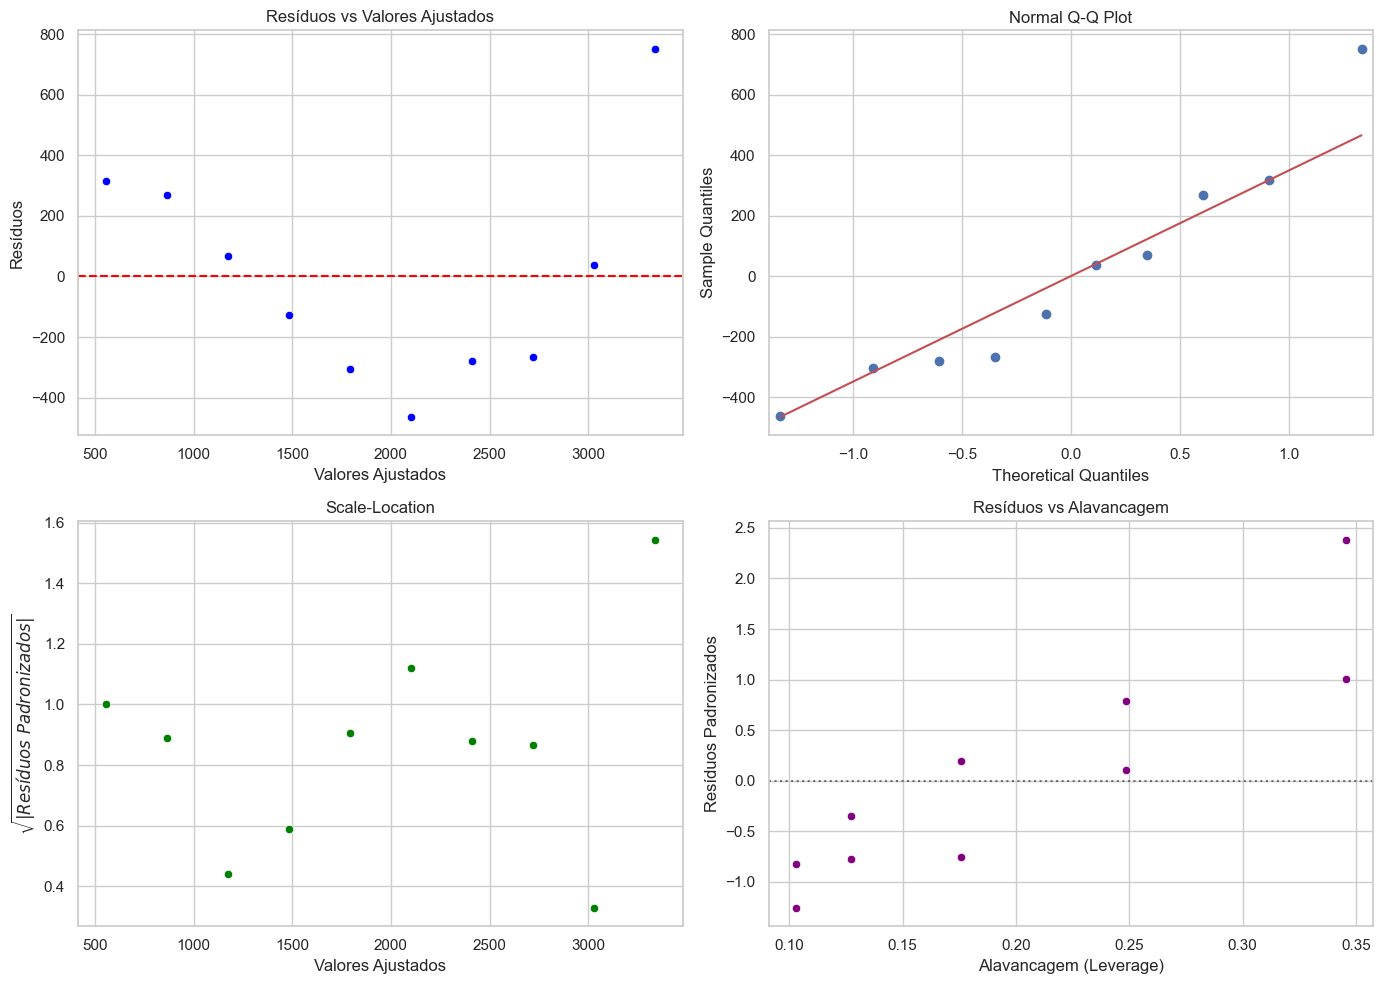

In [4]:
# --- TESTE DE NORMALIDADE DOS RESÍDUOS (Shapiro-Wilk) ---
stat_shapiro, p_valor_shapiro = stats.shapiro(modelo.resid)
print("--- Teste de Normalidade de Shapiro-Wilk nos Resíduos ---")
print(f"Estatística W: {stat_shapiro:.4f} | p-valor: {p_valor_shapiro:.4f}")

if p_valor_shapiro > 0.05:
    print("Conclusão: Não rejeitamos H0. Os resíduos parecem seguir uma distribuição normal.")
else:
    print("Conclusão: Rejeitamos H0. Os resíduos NÃO seguem uma distribuição normal.")

# --- GRÁFICOS DE DIAGNÓSTICO ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Resíduos vs Valores Ajustados (Fitted Values)
sns.scatterplot(x=modelo.fittedvalues, y=modelo.resid, ax=axes[0, 0], color='blue')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Resíduos vs Valores Ajustados')
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Resíduos')

# 2. Q-Q Plot (Normalidade dos Resíduos)
sm.qqplot(modelo.resid, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')

# 3. Raiz dos Resíduos Padronizados vs Valores Ajustados (Scale-Location)
residuos_padronizados = modelo.get_influence().resid_studentized_internal
sns.scatterplot(x=modelo.fittedvalues, y=np.sqrt(np.abs(residuos_padronizados)), ax=axes[1, 0], color='green')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].set_xlabel('Valores Ajustados')
axes[1, 0].set_ylabel('$\sqrt{|Resíduos\ Padronizados|}$')

# 4. Resíduos vs Alavancagem (Leverage) com Distância de Cook
influence = modelo.get_influence()
leverage = influence.hat_matrix_diag
sns.scatterplot(x=leverage, y=residuos_padronizados, ax=axes[1, 1], color='purple')
axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.5)
axes[1, 1].set_title('Resíduos vs Alavancagem')
axes[1, 1].set_xlabel('Alavancagem (Leverage)')
axes[1, 1].set_ylabel('Resíduos Padronizados')

plt.tight_layout()
plt.show()

---
## 📚 Apêndice Teórico:

Por que multiplicar `inv(X.T @ X) @ X.T @ Y` minimiza os erros?

### 1. A Função de Custo (O Alvo)
Queremos minimizar a Soma dos Quadrados dos Resíduos (SZR), que mede a distância entre o que prevemos e a realidade:
$$S(\beta_0, \beta_1) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2$$

### 2. Cálculo Diferencial
Essa função $S$ é uma parábola multidimensional (um "prato"). O menor valor possível de erro está no fundo desse prato. Para achar o fundo, usamos **Derivadas Parciais**, igualando-as a zero (onde a inclinação é nula).

Derivando para o Intercepto ($\beta_0$):
$$\frac{\partial S}{\partial \beta_0} = -2 \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i) = 0$$

Derivando para a Inclinação ($\beta_1$):
$$\frac{\partial S}{\partial \beta_1} = -2 \sum_{i=1}^{n} x_i(y_i - \beta_0 - \beta_1 x_i) = 0$$

### 3. O Sistema de Equações Normais
Se expandirmos e reorganizarmos as duas equações acima, teremos um sistema linear, apelidado de *Equações Normais*:
1) $n\beta_0 + \beta_1 \sum x_i = \sum y_i$
2) $\beta_0 \sum x_i + \beta_1 \sum x_i^2 = \sum x_i y_i$

Surpresa: Se você escrever esse sistema exato na forma de matrizes, você chega exatamente em **$X^T X \beta = X^T Y$**. Ao isolar o vetor $\beta$, invertemos a matriz da esquerda e chegamos na fórmula de código que usamos!